# Hotel Booking Demand Analysis

## Objective
This project analyzes hotel booking data to understand booking patterns,
cancellations, pricing, and customer behavior.

The analysis focuses on identifying factors associated with booking cancellations
and examining how demand and pricing vary across hotels and time.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("hotel_bookings.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (119390, 32)


In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [55]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_of_special_requests,reservation_status,reservation_status_date,total_guests,arrival_month_num,arrival_date,total_nights,estimated_revenue,lead_time_category,adr_level
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,Check-Out,2017-09-06,2.0,8,2017-08-30,7,672.98,8-30 days,Below Median
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,2,Check-Out,2017-09-07,3.0,8,2017-08-31,7,1578.01,91-180 days,Above/Equal Median
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,4,Check-Out,2017-09-07,2.0,8,2017-08-31,7,1103.97,31-90 days,Above/Equal Median
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,Check-Out,2017-09-07,2.0,8,2017-08-31,7,730.80,91-180 days,Above/Equal Median
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,2,Check-Out,2017-09-07,2.0,8,2017-08-29,9,1360.80,180+ days,Above/Equal Median


In [6]:
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
76512,City Hotel,1,195,2015,September,38,17,0,2,2,...,No Deposit,20.0,NaN,0,Transient,48.00,0,0,Canceled,2015-07-23
54240,City Hotel,1,136,2016,July,28,9,2,3,2,...,No Deposit,9.0,NaN,0,Transient,172.55,0,0,Canceled,2016-02-24
12200,Resort Hotel,1,251,2017,June,24,17,3,6,2,...,No Deposit,240.0,NaN,0,Transient,108.90,0,1,Canceled,2016-10-18
36797,Resort Hotel,0,274,2017,May,22,28,1,0,1,...,No Deposit,240.0,NaN,0,Transient,93.60,0,1,Check-Out,2017-05-29
76342,City Hotel,0,271,2015,July,29,15,0,2,3,...,No Deposit,1.0,NaN,0,Transient-Party,84.00,0,0,Check-Out,2015-07-17


In [65]:
df.dtypes

hotel                                        str
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                           str
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                         str
country                                      str
market_segment                               str
distribution_channel                         str
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                           str
assigned_room_type  

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

company     112593
agent        16340
country        488
children         4
dtype: int64

In [10]:
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent[missing_percent > 0]

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

In [11]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [12]:
df.describe(include="object")

C:\Users\walaa\AppData\Local\Temp\ipykernel_19952\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


## Column Description

- hotel: Type of hotel
- is_canceled: Whether the booking was canceled
- lead_time: Number of days between booking and arrival
- arrival_date_year: Arrival year
- arrival_date_month: Arrival month
- arrival_date_week_number: Arrival week number
- arrival_date_day_of_month: Arrival day
- stays_in_weekend_nights: Weekend nights stayed
- stays_in_week_nights: Week nights stayed
- adults: Number of adults
- children: Number of children
- babies: Number of babies
- meal: Meal type
- country: Customer country
- market_segment: Market segment
- distribution_channel: Distribution channel
- is_repeated_guest: Whether the guest is a repeated guest
- previous_cancellations: Previous cancellations
- previous_bookings_not_canceled: Previous successful bookings
- reserved_room_type: Reserved room type
- assigned_room_type: Assigned room type
- booking_changes: Number of booking changes
- deposit_type: Deposit type
- agent: Booking agent
- company: Company associated with the booking
- days_in_waiting_list: Days spent on waiting list
- customer_type: Customer type
- adr: Average Daily Rate
- required_car_parking_spaces: Required parking spaces
- total_of_special_requests: Number of special requests
- reservation_status: Final reservation status
- reservation_status_date: Date of reservation status

In [16]:
df["total_guests"] = (
    df["adults"] +
    df["children"].fillna(0) +
    df["babies"]
)

print("Bookings with zero guests:", (df["total_guests"] == 0).sum())

Bookings with zero guests: 180


In [14]:
print("Bookings with ADR <= 0:", (df["adr"] <= 0).sum())

Bookings with ADR <= 0: 1960


In [15]:
print("Missing children values:", df["children"].isnull().sum())

Missing children values: 4


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (87396, 33)


In [22]:
df["children"] = df["children"].fillna(0)

In [23]:
df["country"] = df["country"].fillna("Unknown")

In [24]:
df["agent"] = df["agent"].fillna(0)

In [25]:
df["company"] = df["company"].fillna(0)

In [26]:
month_map = {"January": 1,"February": 2,"March": 3,"April": 4,"May": 5,"June": 6,"July": 7,
    "August": 8,"September": 9,"October": 10,"November": 11,"December": 12}

df["arrival_month_num"] = df["arrival_date_month"].map(month_map)

df["arrival_date"] = pd.to_datetime(
    dict(
        year=df["arrival_date_year"],
        month=df["arrival_month_num"],
        day=df["arrival_date_day_of_month"]
    )
)

df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"]
)

In [28]:
df = df[df["adr"] >= 0].copy()

In [29]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

In [32]:
df["estimated_revenue"] = (
    df["adr"] * df["total_nights"]
)

In [35]:
df["adr_level"] = np.where(
    df["adr"] >= df["adr"].median(),
    "Above/Equal Median",
    "Below Median"
)

df[["adr", "adr_level"]].head(12)

,adr,adr_level
0,0.0,Below Median
1,0.0,Below Median
2,75.0,Below Median
3,75.0,Below Median
4,98.0,Below Median
6,107.0,Above/Equal Median
7,103.0,Above/Equal Median
8,82.0,Below Median
9,105.5,Above/Equal Median
10,123.0,Above/Equal Median


In [36]:
hotel_summary = df.groupby("hotel").agg(
    bookings=("hotel", "size"),
    cancellations=("is_canceled", "sum"),
    average_adr=("adr", "mean"),
    average_lead_time=("lead_time", "mean")
)

hotel_summary

,bookings,cancellations,average_adr,average_lead_time
hotel,,,,
City Hotel,53274,16035,111.271969,77.793257
Resort Hotel,33955,7974,99.062622,83.384450


In [37]:
hotel_summary["cancellation_rate"] = (
    hotel_summary["cancellations"] /
    hotel_summary["bookings"] * 100
)

hotel_summary

,bookings,cancellations,average_adr,average_lead_time,cancellation_rate
hotel,,,,,
City Hotel,53274,16035,111.271969,77.793257,30.099110
Resort Hotel,33955,7974,99.062622,83.384450,23.484023


In [41]:
monthly_analysis = df.groupby(["arrival_date_year", "arrival_date_month"],
    observed=True
).agg(
    bookings=("hotel", "size"),
    cancellation_rate=("is_canceled", "mean"),
    average_adr=("adr", "mean")
).reset_index()

monthly_analysis["cancellation_rate"] *= 100

monthly_analysis.head()

,arrival_date_year,arrival_date_month,bookings,cancellation_rate,average_adr
0,2015,August,2447,23.334696,123.295971
1,2015,December,1975,18.835443,71.793853
2,2015,July,1672,30.622010,112.533828
3,2015,November,1662,14.620939,59.339651


In [39]:
lead_time_analysis = df.groupby(
    "lead_time_category",
    observed=True
).agg(
    bookings=("hotel", "size"),
    cancellation_rate=("is_canceled", "mean"),
    average_adr=("adr", "mean")
).reset_index()

lead_time_analysis["cancellation_rate"] *= 100

lead_time_analysis

,lead_time_category,bookings,cancellation_rate,average_adr
0,0-7 days,18203,8.416195,91.677463
1,8-30 days,16326,25.388950,110.696176
2,31-90 days,22720,32.042254,111.345743
3,91-180 days,18224,35.008780,114.174040
4,180+ days,11756,39.741409,102.506005


In [44]:
## Analytical Question

#What booking patterns and customer characteristics are associated
#with higher cancellation rates?

#The analysis will examine cancellation rates across hotels,
#lead-time categories, customer types, and market segments.#

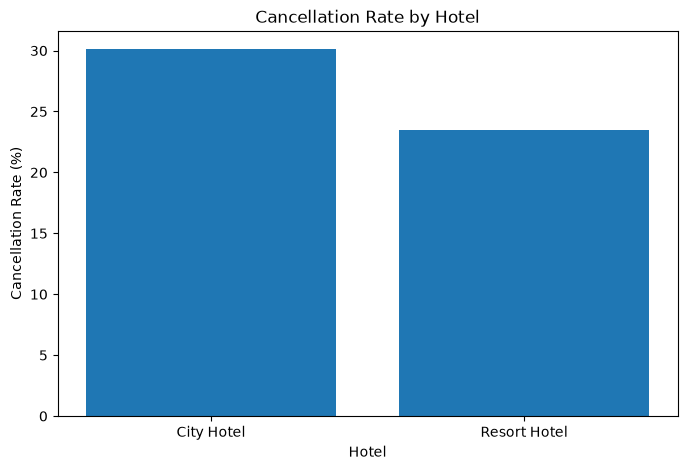

In [46]:
hotel_cancel = df.groupby("hotel")["is_canceled"].mean() * 100

plt.figure(figsize=(8, 5))

plt.bar(
    hotel_cancel.index,
    hotel_cancel.values
)

plt.title("Cancellation Rate by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate (%)")

plt.show()

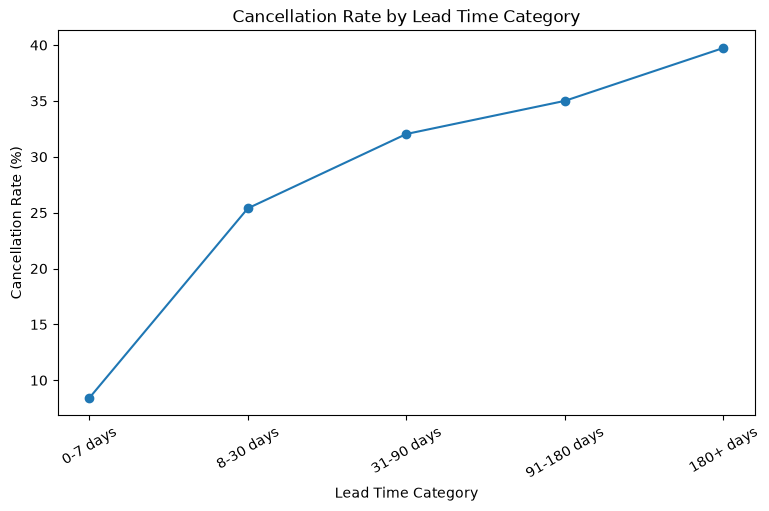

In [47]:
lead_cancel = df.groupby(
    "lead_time_category",
    observed=True
)["is_canceled"].mean() * 100

plt.figure(figsize=(9, 5))

plt.plot(
    lead_cancel.index.astype(str),
    lead_cancel.values,
    marker="o"
)

plt.title("Cancellation Rate by Lead Time Category")
plt.xlabel("Lead Time Category")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=30)

plt.show()

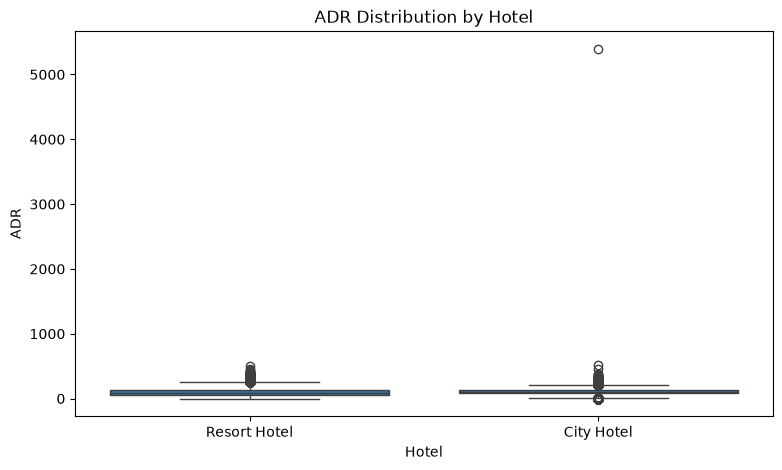

In [48]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="hotel",
    y="adr"
)

plt.title("ADR Distribution by Hotel")
plt.xlabel("Hotel")
plt.ylabel("ADR")

plt.show()

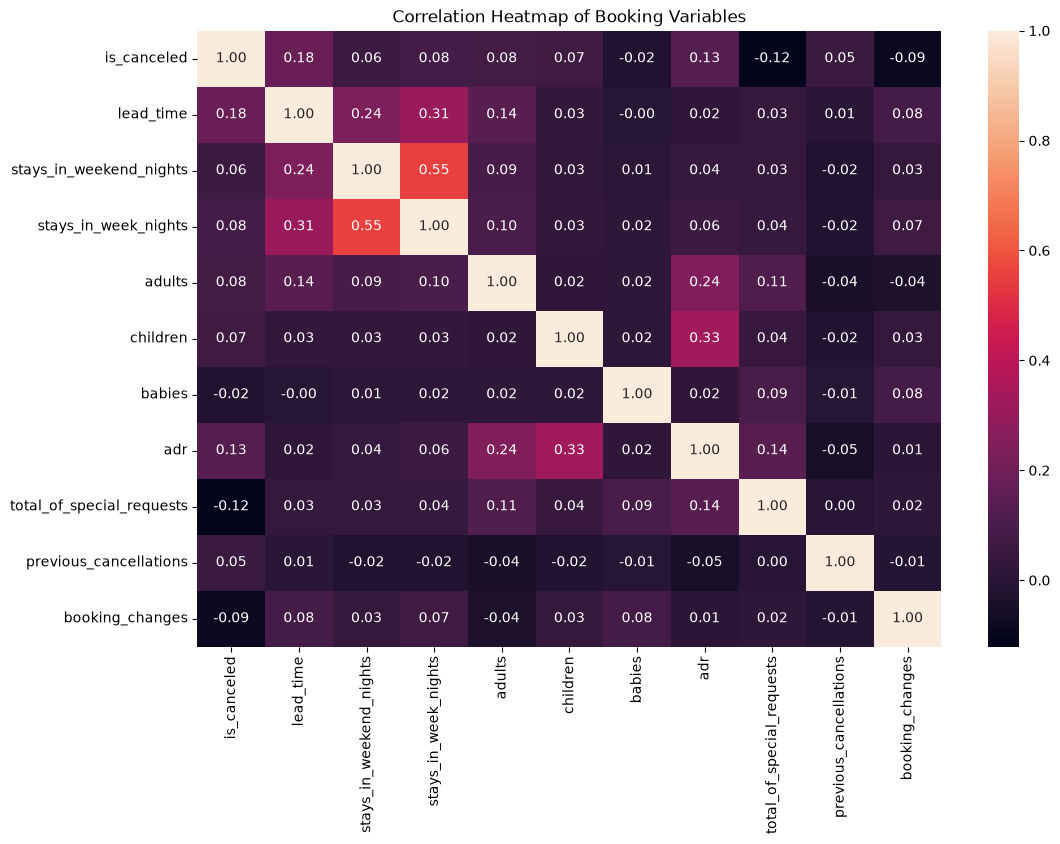

In [51]:
numeric_cols = [
    "is_canceled",
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "adr",
    "total_of_special_requests",
    "previous_cancellations",
    "booking_changes"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Booking Variables")

plt.show()

In [52]:
customer_analysis = df.groupby(
    "customer_type"
).agg(
    bookings=("hotel", "size"),
    cancellation_rate=("is_canceled", "mean"),
    average_lead_time=("lead_time", "mean"),
    average_adr=("adr", "mean")
).reset_index()

customer_analysis["cancellation_rate"] *= 100

customer_analysis.sort_values(
    "cancellation_rate",
    ascending=False
)

,customer_type,bookings,cancellation_rate,average_lead_time,average_adr
2,Transient,71862,30.142495,73.500571,110.302799
0,Contract,3135,16.331738,109.364593,92.871381
3,Transient-Party,11691,15.251048,113.153537,87.927138
1,Group,541,9.796673,51.835490,84.817930


In [53]:
segment_analysis = df.groupby(
    "market_segment"
).agg(
    bookings=("hotel", "size"),
    cancellation_rate=("is_canceled", "mean"),
    average_lead_time=("lead_time", "mean")
).reset_index()

segment_analysis["cancellation_rate"] *= 100

segment_analysis.sort_values(
    "cancellation_rate",
    ascending=False
)

,market_segment,bookings,cancellation_rate,average_lead_time
7,Undefined,2,100.000000,1.500000
6,Online TA,51553,35.384944,79.965589
4,Groups,4921,27.067669,147.906320
0,Aviation,226,19.911504,4.296460
5,Offline TA/TO,13855,14.846626,106.166727
3,Direct,11780,14.745331,48.864516
1,Complementary,692,12.283237,13.823699
2,Corporate,4200,12.119048,16.252381


## Key Findings

The analysis examined hotel booking patterns and cancellation behavior.

The main factors investigated were:
- Hotel type
- Lead time
- Customer type
- Market segment
- Average Daily Rate (ADR)

The results show differences in cancellation behavior across these
booking characteristics.

Longer lead times, customer characteristics, and market segments
can be compared to identify booking patterns associated with
higher cancellation rates.

These findings can help hotel management better understand
cancellation risk and booking behavior.